In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données horaires
df = pd.read_csv(
    "../data/raw/rte/rte_consommation_horaire_2019_2025.csv",
    parse_dates=["date_heure"]
)

print("Données chargées avec succès.")
print(f"Nombre de lignes : {len(df):,}")
print(f"Nombre de colonnes : {len(df.columns)}")

Données chargées avec succès.
Nombre de lignes : 61,368
Nombre de colonnes : 2


In [2]:
df.head()

,date_heure,consommation_mw
0,2019-01-01 00:00:00+00:00,60826.0
1,2019-01-01 01:00:00+00:00,59786.5
2,2019-01-01 02:00:00+00:00,56622.0
3,2019-01-01 03:00:00+00:00,53919.5
4,2019-01-01 04:00:00+00:00,52972.0


vérifie le type de chaque colonne et détecter immédiatement un problème de format.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61368 entries, 0 to 61367
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   date_heure       61368 non-null  datetime64[ns, UTC]
 1   consommation_mw  61361 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(1)
memory usage: 959.0 KB


des statistiques descriptives sur la consommation : moyenne, écart-type, minimum, maximum, quartiles, etc.

In [6]:
df.describe()

,consommation_mw
count,61361.000000
mean,51417.400670
std,11049.184188
min,29364.500000
25%,43218.500000
50%,49660.500000
75%,58697.500000
max,88106.000000


la première et la dernière date disponibles. ( verifier 2019 et 2025 )

In [7]:
print("Première date :", df["date_heure"].min())
print("Dernière date :", df["date_heure"].max())

print(
    "\nNombre de jours :",
    df["date_heure"].dt.date.nunique()
)

Première date : 2019-01-01 00:00:00+00:00
Dernière date : 2025-12-31 23:00:00+00:00

Nombre de jours : 2557


recherche les valeurs manquantes dans chaque colonne.

In [8]:
valeurs_manquantes = df.isna().sum()

print("Nombre de valeurs manquantes par colonne :")
print(valeurs_manquantes)

print("\nPourcentage de valeurs manquantes :")
print(
    (df.isna().mean() * 100).round(2)
)

Nombre de valeurs manquantes par colonne :
date_heure         0
consommation_mw    7
dtype: int64

Pourcentage de valeurs manquantes :
date_heure         0.00
consommation_mw    0.01
dtype: float64


Doublons

In [9]:
nombre_doublons = df["date_heure"].duplicated().sum()

print(
    f"Nombre de dates/heures en doublon : {nombre_doublons}"
)

if nombre_doublons == 0:
    print("Aucun doublon détecté.")
else:
    print("Des doublons ont été détectés.")

Nombre de dates/heures en doublon : 0
Aucun doublon détecté.


Vérifier les intervalles temporels

In [11]:


df_temp = df.sort_values("date_heure").copy()

# Calcul de l'écart entre deux observations successives
df_temp["ecart"] = df_temp["date_heure"].diff()

# Afficher les intervalles les plus fréquents
print("Intervalles les plus fréquents :")
print(
    df_temp["ecart"]
    .value_counts()
    .head(10)
)

# Rechercher uniquement les vrais intervalles anormaux
intervalles_anormaux = df_temp[
    df_temp["ecart"].notna() &
    (df_temp["ecart"] != pd.Timedelta(hours=1))
][
    ["date_heure", "ecart"]
]

print("\nIntervalles différents de 1 heure :")
print(intervalles_anormaux.head(20))

print(
    f"\nNombre de vrais intervalles anormaux : "
    f"{len(intervalles_anormaux)}"
)

Intervalles les plus fréquents :
ecart
0 days 01:00:00    61367
Name: count, dtype: int64

Intervalles différents de 1 heure :
Empty DataFrame
Columns: [date_heure, ecart]
Index: []

Nombre de vrais intervalles anormaux : 0


Consommation minimale et maximale

In [12]:


print("Consommation minimale :")
print(
    df.loc[
        df["consommation_mw"].idxmin()
    ]
)

print("\nConsommation maximale :")
print(
    df.loc[
        df["consommation_mw"].idxmax()
    ]
)

Consommation minimale :
date_heure         2020-05-10 05:00:00+00:00
consommation_mw                      29364.5
Name: 11885, dtype: object

Consommation maximale :
date_heure         2019-01-24 18:00:00+00:00
consommation_mw                      88106.0
Name: 570, dtype: object


visualiser l'évolution globale de la consommation entre 2019 et 2025.

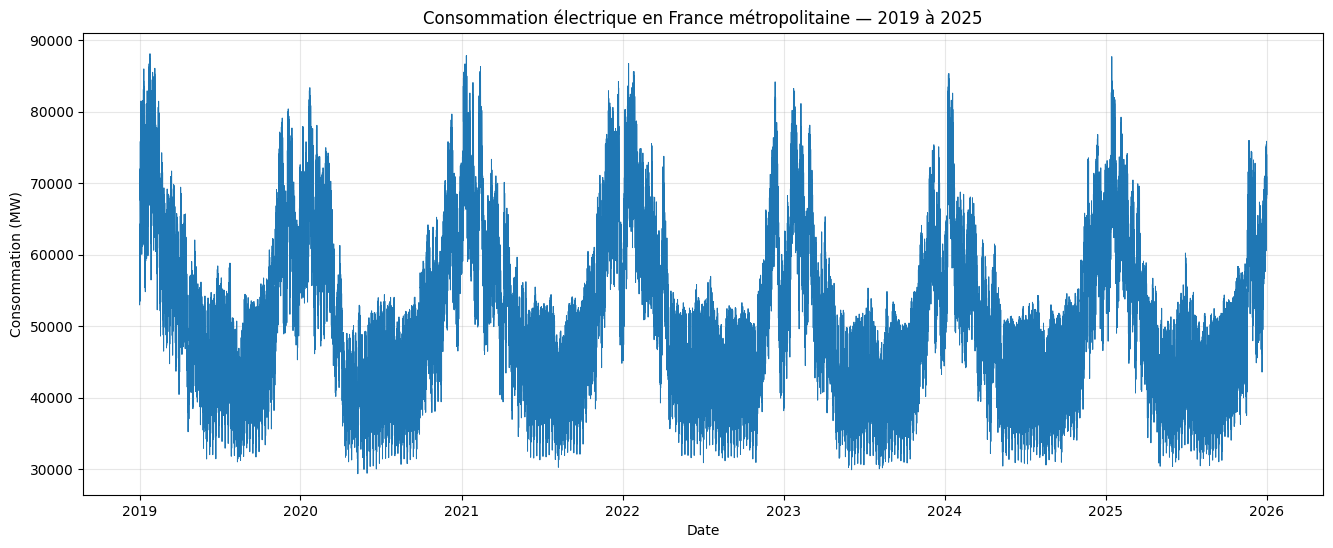

In [ ]:


plt.figure(figsize=(16, 6))

plt.plot(
    df["date_heure"],
    df["consommation_mw"],
    linewidth=0.7
)

plt.title(
    "Consommation électrique en France métropolitaine — 2019 à 2025"
)

plt.xlabel("Date")
plt.ylabel("Consommation (MW)")

plt.grid(True, alpha=0.3)

plt.show()

Une courbe sur 7 jours est beaucoup plus lisible 

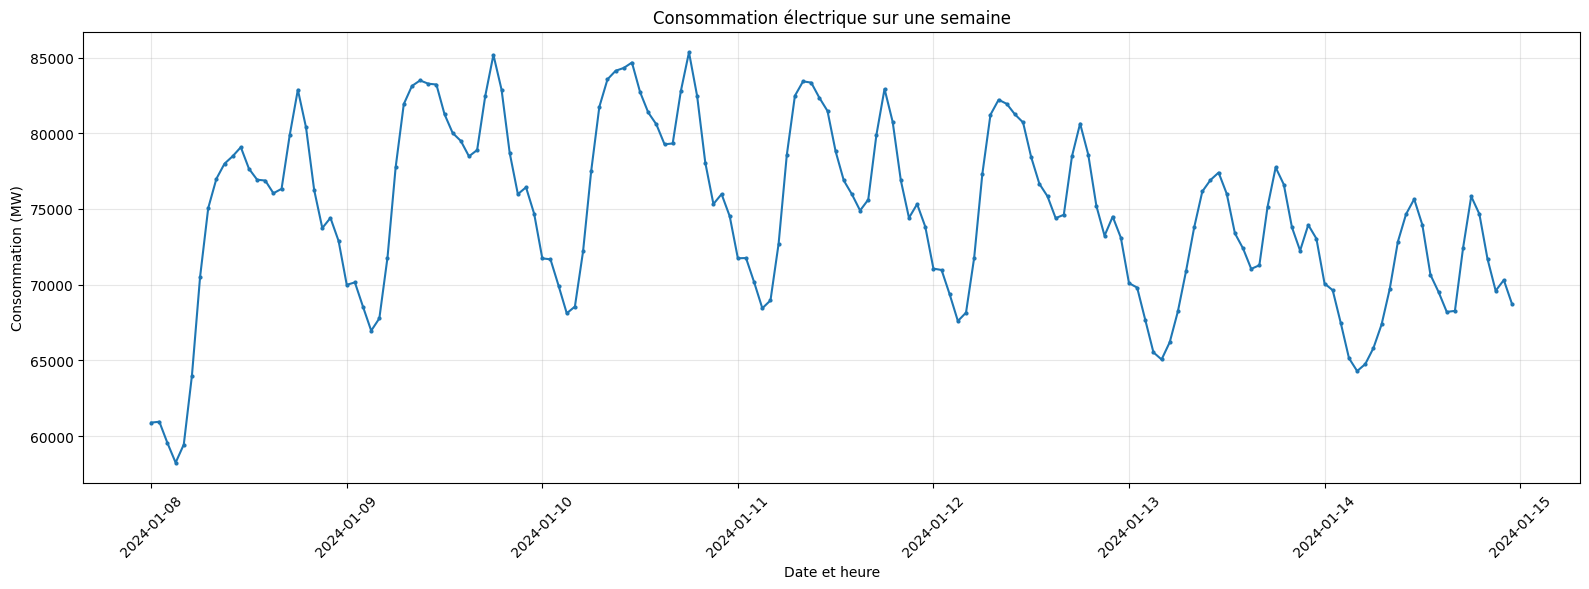

In [ ]:


# Choisir une semaine située dans la période étudiée
semaine = df[
    (df["date_heure"] >= "2024-01-08") &
    (df["date_heure"] < "2024-01-15")
]

plt.figure(figsize=(16, 6))

plt.plot(
    semaine["date_heure"],
    semaine["consommation_mw"],
    marker="o",
    markersize=2
)

plt.title(
    "Consommation électrique sur une semaine"
)

plt.xlabel("Date et heure")
plt.ylabel("Consommation (MW)")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Profil moyen selon l'heure

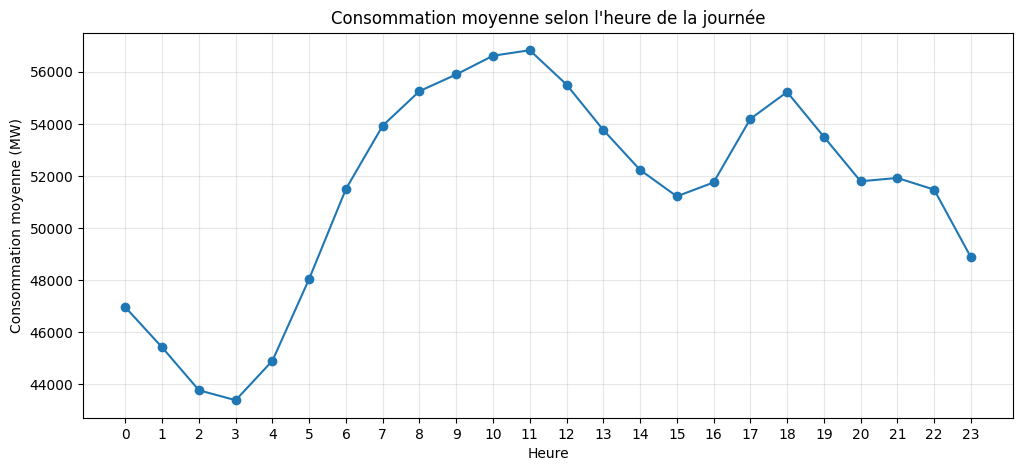

In [ ]:


df["heure"] = df["date_heure"].dt.hour

profil_horaire = (
    df.groupby("heure")["consommation_mw"]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    profil_horaire.index,
    profil_horaire.values,
    marker="o"
)

plt.title(
    "Consommation moyenne selon l'heure de la journée"
)

plt.xlabel("Heure")
plt.ylabel("Consommation moyenne (MW)")

plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()

Consommation selon le jour de la semaine

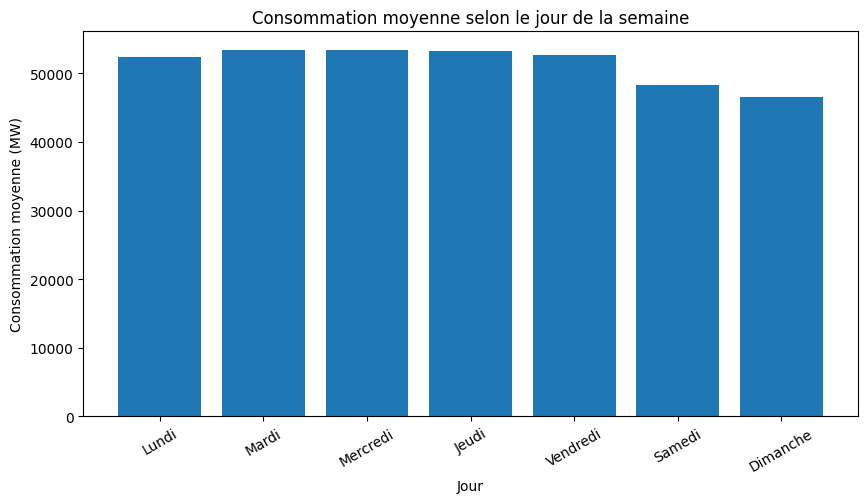

In [ ]:


jours = [
    "Lundi",
    "Mardi",
    "Mercredi",
    "Jeudi",
    "Vendredi",
    "Samedi",
    "Dimanche"
]

df["jour_semaine"] = df["date_heure"].dt.dayofweek

profil_jour = (
    df.groupby("jour_semaine")["consommation_mw"]
    .mean()
)

profil_jour.index = [
    jours[i] for i in profil_jour.index
]

plt.figure(figsize=(10, 5))

plt.bar(
    profil_jour.index,
    profil_jour.values
)

plt.title(
    "Consommation moyenne selon le jour de la semaine"
)

plt.xlabel("Jour")
plt.ylabel("Consommation moyenne (MW)")

plt.xticks(rotation=30)

plt.show()

Consommation moyenne par mois

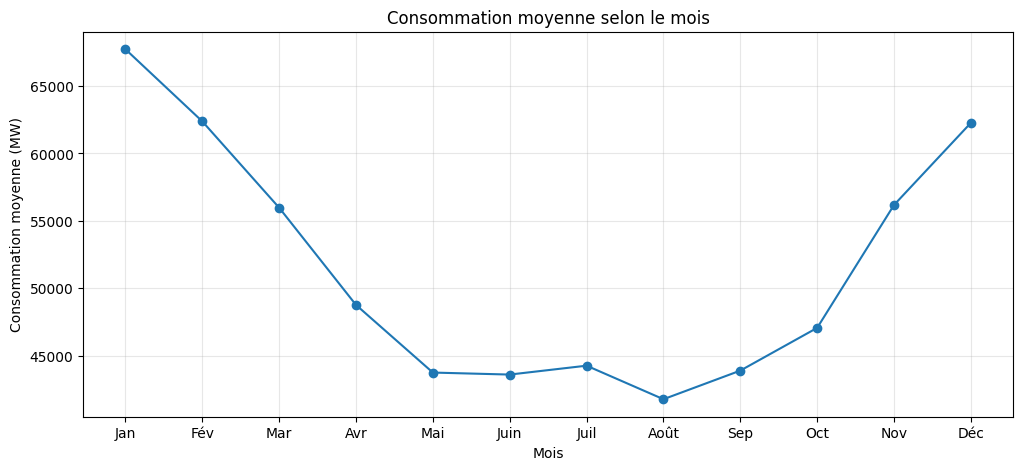

In [ ]:


df["mois"] = df["date_heure"].dt.month

profil_mois = (
    df.groupby("mois")["consommation_mw"]
    .mean()
)

noms_mois = [
    "Jan", "Fév", "Mar", "Avr",
    "Mai", "Juin", "Juil", "Août",
    "Sep", "Oct", "Nov", "Déc"
]

plt.figure(figsize=(12, 5))

plt.plot(
    profil_mois.index,
    profil_mois.values,
    marker="o"
)

plt.title(
    "Consommation moyenne selon le mois"
)

plt.xlabel("Mois")
plt.ylabel("Consommation moyenne (MW)")

plt.xticks(
    range(1, 13),
    noms_mois
)

plt.grid(True, alpha=0.3)

plt.show()

Profil heure × jour de la semaine

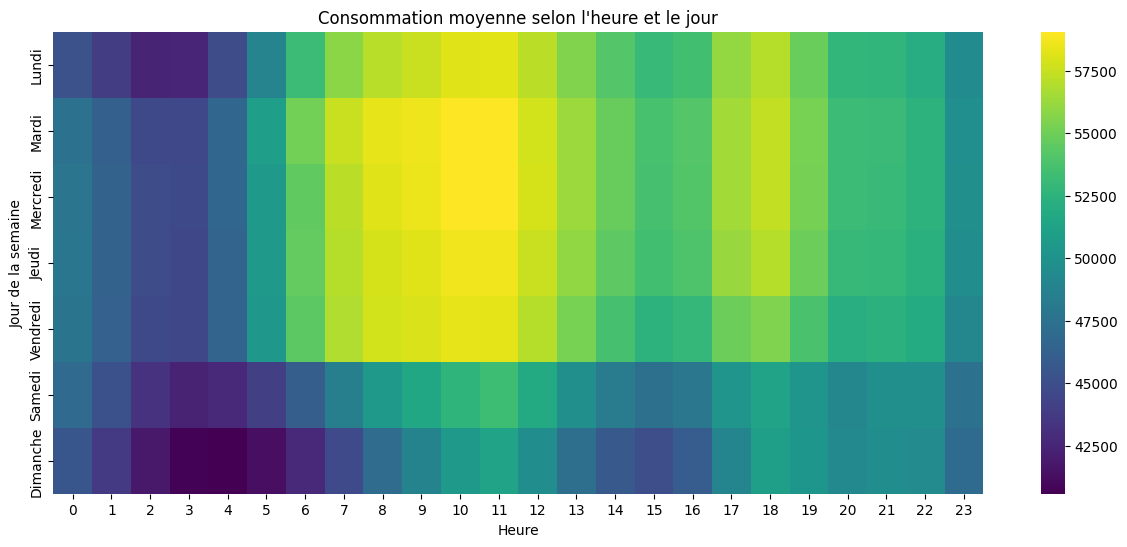

In [ ]:


profil_heure_jour = df.pivot_table(
    values="consommation_mw",
    index="jour_semaine",
    columns="heure",
    aggfunc="mean"
)

profil_heure_jour.index = jours

plt.figure(figsize=(15, 6))

sns.heatmap(
    profil_heure_jour,
    annot=False,
    cmap="viridis"
)

plt.title(
    "Consommation moyenne selon l'heure et le jour"
)

plt.xlabel("Heure")
plt.ylabel("Jour de la semaine")

plt.show()

Consommation journalière

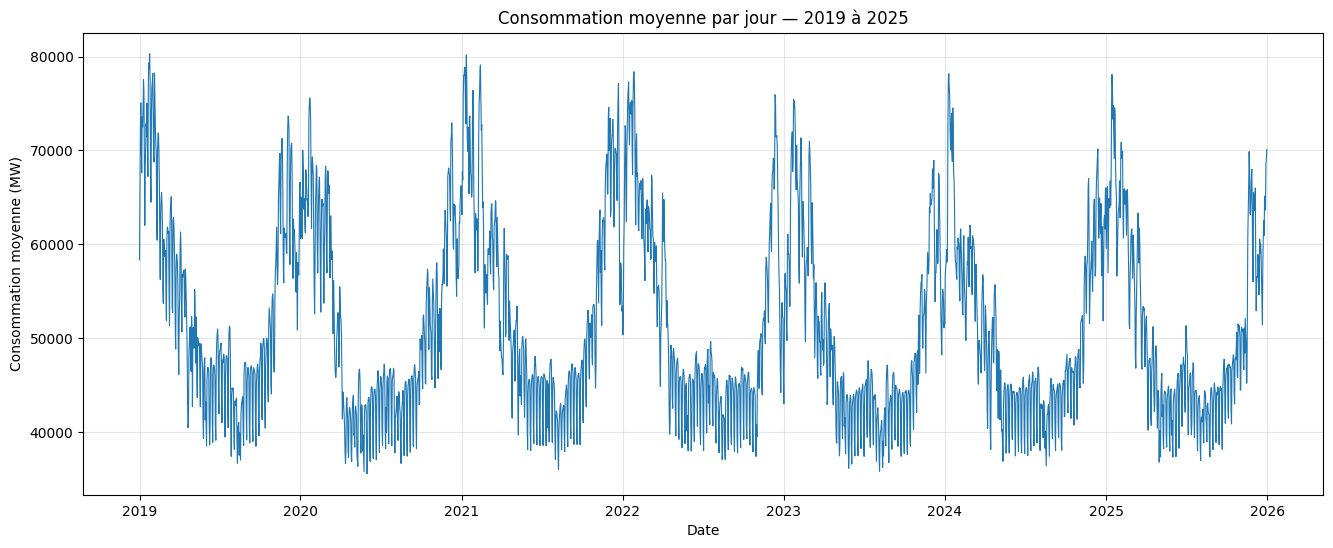

In [ ]:


df["date"] = df["date_heure"].dt.date

consommation_journaliere = (
    df.groupby("date")["consommation_mw"]
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    consommation_journaliere.index,
    consommation_journaliere.values,
    linewidth=0.8
)

plt.title(
    "Consommation moyenne par jour — 2019 à 2025"
)

plt.xlabel("Date")
plt.ylabel("Consommation moyenne (MW)")

plt.grid(True, alpha=0.3)

plt.show()

Distribution de la consommation

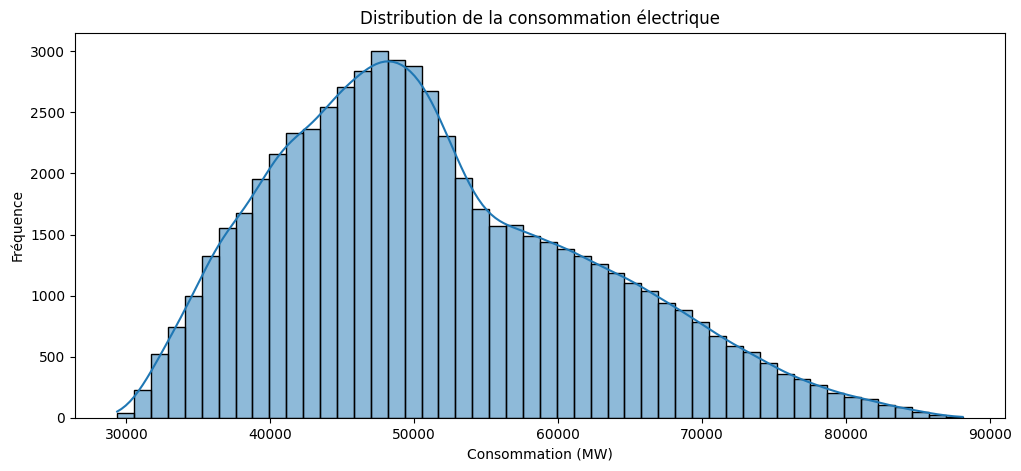

In [ ]:


plt.figure(figsize=(12, 5))

sns.histplot(
    df["consommation_mw"],
    bins=50,
    kde=True
)

plt.title(
    "Distribution de la consommation électrique"
)

plt.xlabel("Consommation (MW)")
plt.ylabel("Fréquence")

plt.show()

Boxplot des consommations

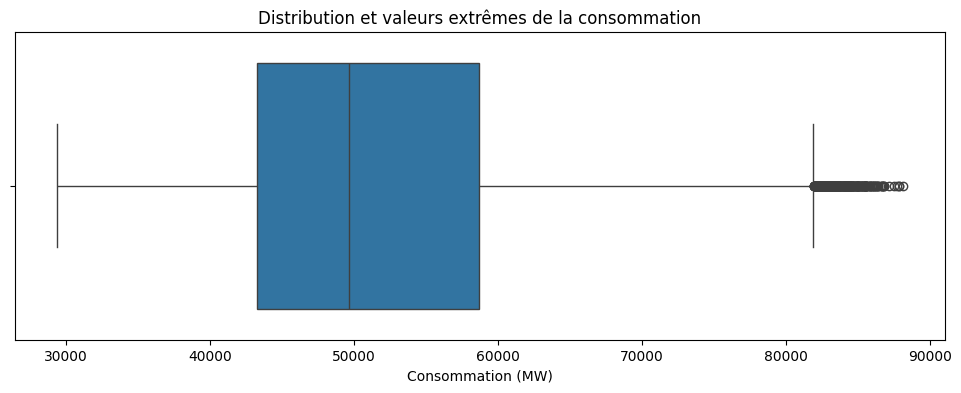

In [ ]:


plt.figure(figsize=(12, 4))

sns.boxplot(
    x=df["consommation_mw"]
)

plt.title(
    "Distribution et valeurs extrêmes de la consommation"
)

plt.xlabel("Consommation (MW)")

plt.show()

Comparaison des années

annee
2019    53708.499543
2020    50840.931231
2021    53491.093447
2022    51387.009704
2023    49724.422708
2024    50102.326654
2025    50672.704304
Name: consommation_mw, dtype: float64


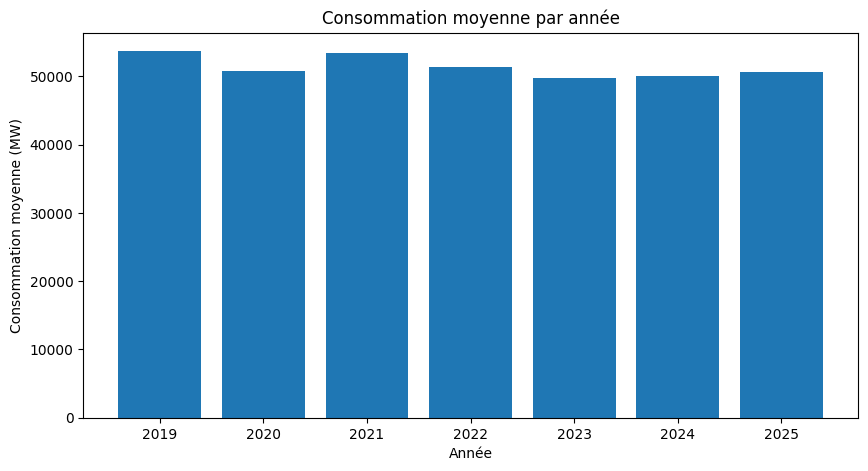

In [ ]:


df["annee"] = df["date_heure"].dt.year

consommation_annuelle = (
    df.groupby("annee")["consommation_mw"]
    .mean()
)

print(consommation_annuelle)

plt.figure(figsize=(10, 5))

plt.bar(
    consommation_annuelle.index.astype(str),
    consommation_annuelle.values
)

plt.title(
    "Consommation moyenne par année"
)

plt.xlabel("Année")
plt.ylabel("Consommation moyenne (MW)")

plt.show()

'ajouter la colonne corona

In [ ]:


# Période considérée comme période COVID/confinement
debut_corona = pd.Timestamp("2020-03-17", tz="UTC")
fin_corona = pd.Timestamp("2021-06-30", tz="UTC")

df["corona"] = (
    (df["date_heure"] >= debut_corona) &
    (df["date_heure"] <= fin_corona)
).map({
    True: "Yes",
    False: "No"
})

print("Répartition de la variable corona :")
print(df["corona"].value_counts())

print("\nAperçu :")
display(
    df[
        [
            "date_heure",
            "consommation_mw",
            "corona"
        ]
    ].head()
)

Répartition de la variable corona :
corona
No     50087
Yes    11281
Name: count, dtype: int64

Aperçu :


,date_heure,consommation_mw,corona
0,2019-01-01 00:00:00+00:00,60826.0,No
1,2019-01-01 01:00:00+00:00,59786.5,No
2,2019-01-01 02:00:00+00:00,56622.0,No
3,2019-01-01 03:00:00+00:00,53919.5,No
4,2019-01-01 04:00:00+00:00,52972.0,No


variable saison

In [27]:
# Création d'une variable saison à partir du mois

def definir_saison(mois):
    if mois in [12, 1, 2]:
        return "Hiver"
    elif mois in [3, 4, 5]:
        return "Printemps"
    elif mois in [6, 7, 8]:
        return "Été"
    else:
        return "Automne"


# Application de la fonction à chaque date
df["saison"] = df["date_heure"].dt.month.map(definir_saison)

# Vérification
print(df[["date_heure", "saison"]].head(20))

                  date_heure saison
0  2019-01-01 00:00:00+00:00  Hiver
1  2019-01-01 01:00:00+00:00  Hiver
2  2019-01-01 02:00:00+00:00  Hiver
3  2019-01-01 03:00:00+00:00  Hiver
4  2019-01-01 04:00:00+00:00  Hiver
5  2019-01-01 05:00:00+00:00  Hiver
6  2019-01-01 06:00:00+00:00  Hiver
7  2019-01-01 07:00:00+00:00  Hiver
8  2019-01-01 08:00:00+00:00  Hiver
9  2019-01-01 09:00:00+00:00  Hiver
10 2019-01-01 10:00:00+00:00  Hiver
11 2019-01-01 11:00:00+00:00  Hiver
12 2019-01-01 12:00:00+00:00  Hiver
13 2019-01-01 13:00:00+00:00  Hiver
14 2019-01-01 14:00:00+00:00  Hiver
15 2019-01-01 15:00:00+00:00  Hiver
16 2019-01-01 16:00:00+00:00  Hiver
17 2019-01-01 17:00:00+00:00  Hiver
18 2019-01-01 18:00:00+00:00  Hiver
19 2019-01-01 19:00:00+00:00  Hiver


In [28]:
# Consommation moyenne selon la saison

moyenne_saison = (
    df.groupby("saison")["consommation_mw"]
    .mean()
    .reindex(["Hiver", "Printemps", "Été", "Automne"])
)

print(moyenne_saison)

saison
Hiver        64180.801853
Printemps    49494.235216
Été          43191.106011
Automne      49014.075388
Name: consommation_mw, dtype: float64


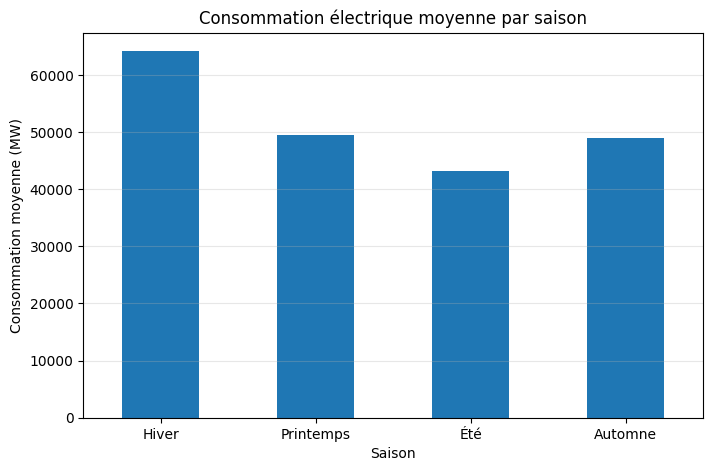

In [29]:
# Graphique de la consommation moyenne par saison

moyenne_saison.plot(
    kind="bar",
    figsize=(8, 5),
    title="Consommation électrique moyenne par saison"
)

plt.ylabel("Consommation moyenne (MW)")
plt.xlabel("Saison")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [30]:
# Vérification finale du dataframe après l'exploration

print("Dimensions du dataframe :", df.shape)

print("\nColonnes disponibles :")
print(df.columns.tolist())

print("\nAperçu des dernières lignes :")
display(df.tail())

print("\nValeurs manquantes :")
print(df.isna().sum())

print("\nPériode couverte :")
print("Début :", df["date_heure"].min())
print("Fin   :", df["date_heure"].max())

print("\nSaisons présentes :")
print(df["saison"].value_counts())

Dimensions du dataframe : (61368, 9)

Colonnes disponibles :
['date_heure', 'consommation_mw', 'heure', 'jour_semaine', 'mois', 'date', 'annee', 'corona', 'saison']

Aperçu des dernières lignes :


,date_heure,consommation_mw,heure,jour_semaine,mois,date,annee,corona,saison
61363,2025-12-31 19:00:00+00:00,72013.5,19,2,12,2025-12-31,2025,No,Hiver
61364,2025-12-31 20:00:00+00:00,69214.5,20,2,12,2025-12-31,2025,No,Hiver
61365,2025-12-31 21:00:00+00:00,68354.0,21,2,12,2025-12-31,2025,No,Hiver
61366,2025-12-31 22:00:00+00:00,70486.0,22,2,12,2025-12-31,2025,No,Hiver
61367,2025-12-31 23:00:00+00:00,70877.0,23,2,12,2025-12-31,2025,No,Hiver



Valeurs manquantes :
date_heure         0
consommation_mw    7
heure              0
jour_semaine       0
mois               0
date               0
annee              0
corona             0
saison             0
dtype: int64

Période couverte :
Début : 2019-01-01 00:00:00+00:00
Fin   : 2025-12-31 23:00:00+00:00

Saisons présentes :
saison
Printemps    15456
Été          15456
Automne      15288
Hiver        15168
Name: count, dtype: int64


In [31]:
# Sauvegarde du dataframe préparé

chemin_sortie = "../data/processed/consommation_electricite_2019_2025.csv"

df.to_csv(chemin_sortie, index=False)

print(f"Dataframe sauvegardé dans : {chemin_sortie}")

Dataframe sauvegardé dans : ../data/processed/consommation_electricite_2019_2025.csv
